# Parameter identifiability of the Pol II pools model

This notebook runs three analyses:

1. Repeated fitting from 250 random initial conditions, to ask if the optimum is unique.
2. Profile likelihood. For each of the 5 parameters, the two derived quantities
   $N_{\text{ss}}/(K_{\text{m}(NP)}+N_{\text{ss}})$ and $P_{\text{ss}}/(K_{\text{m}(PE)}+P_{\text{ss}})$ at $T=1$.
3. Bootstrap resampling, to understand variability of point estimates of parameters and derived quantities.

`polii_model.py` contains the functions used in this notebook. It is refactored for
convenience and uses a different approach to solve the model. It is validates as numerically identical to `pol_pools_mm.ipynb` in a cell of this notebook.

In [13]:
import os, sys, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

sys.path.append(os.getcwd())
os.environ.setdefault("POLII_DATA", "../data")
import polii_model as pm

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.sans-serif": ["Arial", "DejaVu Sans", "sans-serif"],
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "axes.linewidth": 1.0,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)

FIT = dict(w_P=3.0, w_armc5=3.0, pt_fraction=0.8)
data = pm.load_data()
print({k: np.shape(v) for k, v in data.items()})

{'T_E': (71,), 'E': (71,), 'E_block': (71,), 'E3_sd': (5,), 'E_sd': (71,), 'T_B': (33,), 'B': (33,), 'B_block': (33,), 'T_P': (3,), 'P': (3,)}


## Refactoring the solver for fast steady-state evaluation

`polii_model.steady_state` replaces the multi-initial-guess `scipy.optimize.root`
search of the original notebook with a single scalar root-find in $P_{\text{ss}}$.
This section first shows that the steady state is unique and then confirms
numerically that the two solvers agree.

### The model

$$\frac{dN}{dt}=k_{PN}P+k_{EN}E-\frac{V_{\text{max}(NP)}N}{K_{\text{m}(NP)}+N}$$

$$\frac{dP}{dt}=\frac{V_{\text{max}(NP)}N}{K_{\text{m}(NP)}+N}-k_{PN}P-\frac{V_{\text{max}(PE)}P}{K_{\text{m}(PE)}+P}$$

$$\frac{dE}{dt}=\frac{V_{\text{max}(PE)}P}{K_{\text{m}(PE)}+P}-k_{EN}E$$

with $T=N+P+E$ conserved and $k_{EN}=1$ fixed to set the timescale. The three
right-hand sides sum identically to zero, so only two of the three steady-state
conditions are independent.

Throughout, $V_{\text{max}(NP)}$, $V_{\text{max}(PE)}$, $K_{\text{m}(NP)}$,
$K_{\text{m}(PE)}$, $k_{EN}>0$, $k_{PN}\geq 0$ and $T>0$


### Eliminate $E_{\text{ss}}$

Setting $dE/dt=0$,

$$E_{\text{ss}}=\frac{V_{\text{max}(PE)}P_{\text{ss}}}{k_{EN}\left(K_{\text{m}(PE)}+P_{\text{ss}}\right)}\equiv\varepsilon(P_{\text{ss}}).$$

$\varepsilon$ is strictly increasing and bounded, since

$$\varepsilon(0)=0,\qquad \varepsilon'(P)=\frac{V_{\text{max}(PE)}K_{\text{m}(PE)}}{k_{EN}\left(K_{\text{m}(PE)}+P\right)^{2}}>0,\qquad \varepsilon(P)\longrightarrow\frac{V_{\text{max}(PE)}}{k_{EN}}\ \ (P\to\infty).$$

### Eliminate $N_{\text{ss}}$

Conservation gives

$$N_{\text{ss}}=T-P_{\text{ss}}-\varepsilon(P_{\text{ss}})\equiv\nu(P_{\text{ss}}),$$

which is strictly decreasing, with $\nu(0)=T>0$ and
$\nu'(P)=-\left(1+\varepsilon'(P)\right)<0$.


### Derive a single equation in terms of $P_{\text{ss}}$

$dP/dt=0$ gives,

$$0=\frac{V_{\text{max}(NP)}\nu(P)}{K_{\text{m}(NP)}+\nu(P)}-k_{PN}P-\frac{V_{\text{max}(PE)}P}{K_{\text{m}(PE)}+P}\equiv g(P).$$

Every steady state of the full system corresponds to a root of $g$ at which all
three pools are non-negative, and every such root gives a steady state.

$P+E=P+\varepsilon(P)$ is continuous and strictly increasing. It is also zero at $P=0$, and diverges as $P\to\infty$ because $\varepsilon$ is bounded. There is therefore a
unique $P_{\max}>0$ with

$$P_{\max}+\varepsilon(P_{\max})=T,\qquad\text{equivalently}\qquad \nu(P_{\max})=0,$$

and non-negativity of all three pools confines $P_{\text{ss}}$ to
$\left[0,\ P_{\max}\right]$.

Writing $\phi(x)=V_{\text{max}(NP)}x/\left(K_{\text{m}(NP)}+x\right)$, so that
$\phi'(x)=V_{\text{max}(NP)}K_{\text{m}(NP)}/\left(K_{\text{m}(NP)}+x\right)^{2}>0$
for $x\geq0$. Differentiating $g$,

$$g'(P)=\underbrace{\phi'\!\left(\nu(P)\right)\nu'(P)}_{<0\ \text{(}\phi'>0,\ \nu'<0\text{)}}\ \underbrace{-\ k_{PN}}_{\leq 0}\ \underbrace{-\ \frac{V_{\text{max}(PE)}K_{\text{m}(PE)}}{\left(K_{\text{m}(PE)}+P\right)^{2}}}_{<0}\ <\ 0 .$$

so the derivative $g'(P)$ is always negative, and because
$$g(P)=\phi(\nu(P))-k_{PN}P-\frac{V_{\text{max}(PE)}P}{K_{\text{m}(PE)}+P},$$

$$g(0)=\phi\!\left(\nu(0)\right)=\frac{V_{\text{max}(NP)}T}{K_{\text{m}(NP)}+T}>0,$$

and

$$g(P_{\max})=\phi(0)-k_{PN}P_{\max}-\frac{V_{\text{max}(PE)}P_{\max}}{K_{\text{m}(PE)}+P_{\max}}=-k_{PN}P_{\max}-\frac{V_{\text{max}(PE)}P_{\max}}{K_{\text{m}(PE)}+P_{\max}}<0,$$

using $\phi(0)=0$ and $P_{\max}>0$.

Therefore, $g$ is continuous and strictly decreasing on $\left[0,\ P_{\max}\right]$ with
$g(0)>0>g(P_{\max})$, so it has exactly one solution there. The steady state
$\left(N_{\text{ss}},P_{\text{ss}},E_{\text{ss}}\right)$ is therefore unique for
every admissible parameter set and every $T>0$. `steady_state` locates $P_{\max}$
by bisection on $\nu$, then $P_{\text{ss}}$ by bisection on $g$ (`scipy.brentq`
in both cases), and recovers $E_{\text{ss}}$ and $N_{\text{ss}}$ from Steps 1
and 2.

We now confirm that this matches the original root-finding algorithm.

In [ ]:
from scipy.optimize import root


def steady_state_original(T, p):
    """Solver from pol_pools_mm.ipynb."""
    k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np = p
    eqs = lambda v: [
        v[0] + v[1] + v[2] - T,
        Vmax_pe * v[1] / (Km_pe + v[1]) - v[2],
        Vmax_np * v[0] / (Km_np + v[0]) - k_pn * v[1] - Vmax_pe * v[1] / (Km_pe + v[1]),
    ]
    best = None
    for g in (
        [T * 0.5, T * 0.3, T * 0.2],
        [T * 0.7, T * 0.2, T * 0.1],
        [T * 0.2, T * 0.6, T * 0.2],
        [T * 0.1, T * 0.2, T * 0.7],
        [T * 0.8, T * 0.15, T * 0.05],
        [T * 0.33, T * 0.33, T * 0.34],
    ):
        r = root(eqs, g, method="hybr", options={"xtol": 1e-8})
        if r.success and min(r.x) > -1e-8:
            n = np.linalg.norm(r.fun)
            if best is None or n < best[0]:
                best = (n, r.x)
    return best[1] if best else np.full(3, np.nan)


rng = np.random.default_rng(0)
diff = []
for _ in range(500):
    p = np.array([10 ** rng.uniform(np.log10(a), np.log10(b)) for a, b in pm.BOUNDS])
    T = rng.uniform(0.2, 2.0)
    a, b = pm.steady_state(T, p), steady_state_original(T, p)
    if np.all(np.isfinite(b)):
        diff.append(np.max(np.abs(a - b)))
print(
    f"max |new - original| over {len(diff)} random (parameter set, T): {max(diff):.2e}"
)

max |new - original| over 464 random (parameter set, T): 8.25e-12


## 1. Repeated fitting from many initial conditions

In [3]:
t0 = time.time()
ref = pm.fit(data, n_starts=250, seed=7, **FIT)
print(f"{time.time()-t0:.0f} s")

best = ref["params"]
ok = [(c, p) for c, p in ref["all"] if c < 1e5]
at_best = np.array(
    [np.abs(np.log10(p) - np.log10(best)).max() < np.log10(1.05) for _, p in ok]
)
print(
    f"{len(ok)}/250 starts converged; {at_best.sum()} reached the global optimum "
    f"(all 5 parameters within 5%)"
)
print(pd.Series(dict(zip(pm.PARAM_NAMES, best))).round(4).to_string())
print(pd.Series(pm.summarise(best, data, **FIT)).round(4).to_string())

448 s
250/250 starts converged; 115 reached the global optimum (all 5 parameters within 5%)
k_pn       4.1911
Vmax_pe    0.3385
Km_pe      0.0307
Vmax_np    2.7490
Km_np      0.3189
k_pn         4.1911
Vmax_pe      0.3385
Km_pe        0.0307
Vmax_np      2.7490
Km_np        0.3189
N0           0.4013
P0           0.2924
E0           0.3063
s_np_T0.5    0.2714
s_pe_T0.5    0.7883
s_np_T0.7    0.4017
s_pe_T0.7    0.8632
s_np_T1.0    0.5572
s_pe_T1.0    0.9050
T_low        0.6854
T_high          NaN
S_T1         0.0893
cost         0.0024


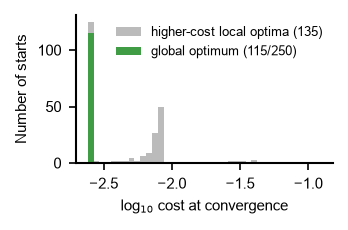

In [14]:
costs = np.array([c for c, _ in ok])
pd.DataFrame(dict(cost=costs, at_global=at_best)).to_csv(
    "table_multistart.csv", index=False
)

# shared bin edges for both histograms: the runs that reach the global optimum all
# land at the same cost (log10 spread < 1e-5), so letting the second hist choose its
# own bins draws it sub-pixel wide and it disappears
edges = np.histogram_bin_edges(np.log10(costs), bins=40)
fig, ax = plt.subplots(figsize=(6 / 2.54, 4 / 2.54))
ax.hist(
    np.log10(costs),
    bins=edges,
    color="#bbbbbb",
    edgecolor="none",
    label=f"higher-cost local optima ({(~at_best).sum()})",
)
ax.hist(
    np.log10(costs[at_best]),
    bins=edges,
    color="#419c46",
    edgecolor="none",
    label=f"global optimum ({at_best.sum()}/{len(ok)})",
)
ax.set_xlabel("log$_{10}$ cost at convergence")
ax.set_ylabel("Number of starts")
ax.legend(frameon=False, fontsize=6, loc="upper right")
fig.tight_layout()
fig.savefig(
    "plots/fig_multistart.pdf",
)

## Profile likelihood

The cost is a weighted sum of squares, $\mathrm{SSE}(\theta)$, over $n_{\rm eff}$
effective observations. Treating the weighted residuals as Gaussian with a common
unknown scale, $\hat\sigma^2=\mathrm{SSE}_{\min}/(n_{\rm eff}-5)$, the profile
likelihood-ratio statistic is
$\Delta\chi^2(\theta_i)=[\mathrm{SSE}(\theta_i)-\mathrm{SSE}_{\min}]/\hat\sigma^2$
and the pointwise 95% confidence interval is the set where
$\Delta\chi^2\le\chi^2_{0.95,1}=3.84$.
The premature-termination penalty is kept active while profiling, but only the data residuals enter $\Delta\chi^2$.

In [15]:
info0 = pm.cost(best, data, full=True, **FIT)
SSE0, NEFF = info0["sse"], info0["n_eff"]
SIG2 = SSE0 / (NEFF - 5)
THRESH = 3.841
print(f"SSE_min = {SSE0:.5g}, n_eff = {NEFF:.0f}, sigma^2_hat = {SIG2:.5g}")


def outward_grid(x0, lo, hi, n=16, first_step=1.02):
    """Multiplicative grid walking outwards from x0: fine near the optimum
    (2% steps), coarse far away."""
    return (
        np.r_[x0, x0 * np.geomspace(first_step, hi / x0, n)],
        np.r_[x0, x0 * np.geomspace(1 / first_step, lo / x0, n)],
    )


def _cross(xs, ds, thresh):
    """First crossing of `thresh` walking outwards along (xs, ds); linear interp."""
    for k in range(1, len(ds)):
        if ds[k] >= thresh:
            if ds[k] == ds[k - 1]:
                return xs[k]
            t = (thresh - ds[k - 1]) / (ds[k] - ds[k - 1])
            return xs[k - 1] + t * (xs[k] - xs[k - 1])
    return np.nan  # threshold not reached inside the grid


def ci_from_profile(value, dchi2, thresh=THRESH):
    """95% profile-likelihood interval; NaN on a side that never crosses."""
    v, d = np.asarray(value, float), np.asarray(dchi2, float)
    o = np.argsort(v)
    v, d = v[o], d[o]
    i0 = int(np.argmin(d))
    return (
        _cross(v[: i0 + 1][::-1], d[: i0 + 1][::-1], thresh),
        _cross(v[i0:], d[i0:], thresh),
    )


def profile_param(idx, lo, hi, n=16):
    """Profile likelihood for parameter `idx`: fix it, re-optimise the other four,
    walking outwards from the optimum in both directions (warm starts)."""
    rows = []
    up, dn = outward_grid(best[idx], lo, hi, n)
    free = [i for i in range(5) if i != idx]
    for direction in (up, dn):
        x = best.copy()
        for v in direction:
            r = minimize(
                lambda xf: pm.cost(np.insert(xf, idx, v), data, **FIT),
                x[free],
                method="L-BFGS-B",
                bounds=[pm.BOUNDS[i] for i in free],
                options={"maxiter": 2000},
            )
            x = np.insert(r.x, idx, v)
            i2 = pm.cost(x, data, full=True, **FIT)
            s_np, s_pe = pm.saturation(1.0, x)
            rows.append(
                dict(
                    param=pm.PARAM_NAMES[idx],
                    value=v,
                    dchi2=(i2["sse"] - SSE0) / SIG2,
                    penalty=i2["penalty"],
                    s_np=s_np,
                    s_pe=s_pe,
                )
            )
    return pd.DataFrame(rows).sort_values("value")


ranges = {
    "k_pn": (0.2, 10),
    "Vmax_pe": (0.05, 3),
    "Km_pe": (1e-4, 2),
    "Vmax_np": (0.3, 20),
    "Km_np": (0.01, 5),
}
t0 = time.time()
prof = pd.concat([profile_param(i, *ranges[n]) for i, n in enumerate(pm.PARAM_NAMES)])
prof.to_csv("profile_parameters.csv", index=False)
print(
    f"{time.time()-t0:.0f} s; max premature-termination penalty along the "
    f"profiles = {prof.penalty.max():.2e} (cost at optimum {ref['cost']:.2e})"
)

ci = pd.DataFrame(
    [
        dict(
            param=n,
            best=best[i],
            ci_low=ci_from_profile(
                prof.loc[prof.param == n, "value"], prof.loc[prof.param == n, "dchi2"]
            )[0],
            ci_high=ci_from_profile(
                prof.loc[prof.param == n, "value"], prof.loc[prof.param == n, "dchi2"]
            )[1],
        )
        for i, n in enumerate(pm.PARAM_NAMES)
    ]
)
ci["rel_width"] = (ci.ci_high - ci.ci_low) / ci.best
print(ci.round(4).to_string(index=False))

SSE_min = 0.29714, n_eff = 123, sigma^2_hat = 0.0025182
64 s; max premature-termination penalty along the profiles = 2.44e-02 (cost at optimum 2.42e-03)
  param   best  ci_low  ci_high  rel_width
   k_pn 4.1911  2.9274   5.5815     0.6333
Vmax_pe 0.3385  0.2900   0.3652     0.2220
  Km_pe 0.0307  0.0193   0.0492     0.9711
Vmax_np 2.7490  2.2109   3.2516     0.3786
  Km_np 0.3189  0.2479   0.4018     0.4826


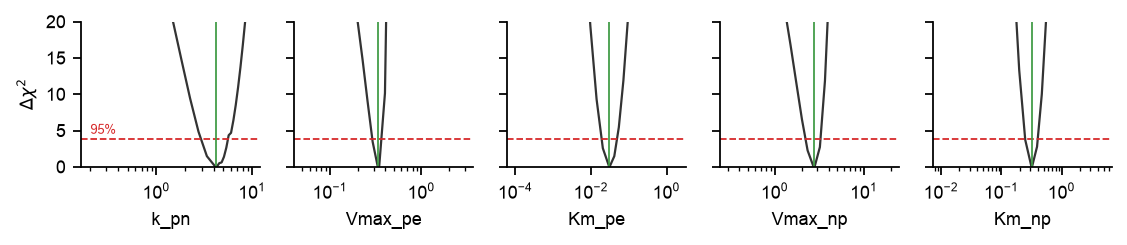

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(18 / 2.54, 4 / 2.54), sharey=True)
for ax, (i, name) in zip(axes, enumerate(pm.PARAM_NAMES)):
    g = prof[prof.param == name]
    ax.plot(g.value, g.dchi2, color="#333333", lw=1)
    ax.axhline(THRESH, color="#d62728", lw=0.8, ls="--")
    ax.axvline(best[i], color="#419c46", lw=0.8)
    ax.set_xscale("log")
    ax.set_ylim(0, 20)
    ax.set_xlabel(name)
axes[0].set_ylabel(r"$\Delta\chi^2$")
axes[0].text(
    0.05,
    THRESH + 0.7,
    "95%",
    color="#d62728",
    fontsize=6,
    transform=axes[0].get_yaxis_transform(),
)
fig.tight_layout()
fig.savefig("fig_profile_parameters.pdf")

## Profile likelihood of the saturation levels

More important is the reliability of saturation levels at $T=1$. We therefore profile those
directly. For a grid of target values we re-fit all five parameters under a
strong penalty that fixes $s_{NP}(1)$ (or $s_{PE}(1)$) to the target, and record the
resulting data SSE.

In [17]:
def profile_saturation(which, targets, w=1e4):
    j = 0 if which == "s_np" else 1
    rows, x = [], best.copy()
    for v in targets:
        r = minimize(
            lambda p: pm.cost(p, data, **FIT) + w * (pm.saturation(1.0, p)[j] - v) ** 2,
            x,
            method="L-BFGS-B",
            bounds=pm.BOUNDS,
            options={"maxiter": 4000},
        )
        x = r.x
        i2 = pm.cost(x, data, full=True, **FIT)
        s_np, s_pe = pm.saturation(1.0, x)
        rows.append(
            dict(
                which=which,
                target=v,
                achieved=(s_np, s_pe)[j],
                s_np=s_np,
                s_pe=s_pe,
                T_low=pm.buffering_range(x)[0],
                S_T1=pm.log_sensitivity(x),
                dchi2=(i2["sse"] - SSE0) / SIG2,
                penalty=i2["penalty"],
            )
        )
    return pd.DataFrame(rows)


s_np0, s_pe0 = pm.saturation(1.0, best)


def sat_targets(
    s0,
    step=np.array(
        [
            0.005,
            0.01,
            0.02,
            0.035,
            0.05,
            0.075,
            0.1,
            0.15,
            0.2,
            0.25,
            0.3,
            0.35,
            0.4,
            0.45,
            0.5,
            0.55,
            0.6,
            0.65,
            0.7,
            0.8,
        ]
    ),
):
    """Targets walking outwards from s0, fine nearby, clipped to (0.01, 0.995)."""
    return (np.clip(s0 + step, 0.01, 0.995), np.clip(s0 - step, 0.01, 0.995))


t0 = time.time()
np_up, np_dn = sat_targets(s_np0)
pe_up, pe_dn = sat_targets(s_pe0)
sat = pd.concat(
    [
        profile_saturation("s_np", np_up),
        profile_saturation("s_np", np_dn),
        profile_saturation("s_pe", pe_up),
        profile_saturation("s_pe", pe_dn),
    ]
).sort_values(["which", "target"])
sat.to_csv("profile_saturation.csv", index=False)
print(
    f"{time.time()-t0:.0f} s; worst |achieved - target| = "
    f"{(sat.achieved - sat.target).abs().max():.3f}"
)

for w, lab in [("s_np", "N->P"), ("s_pe", "P->E")]:
    g = sat[sat.which == w]
    lo, hi = ci_from_profile(g.achieved, g.dchi2)
    print(
        f"{lab} saturation at T=1: best {dict(s_np=s_np0, s_pe=s_pe0)[w]:.3f}, "
        f"95% profile CI [{lo:.3f}, {hi:.3f}]"
    )

49 s; worst |achieved - target| = 0.005
N->P saturation at T=1: best 0.557, 95% profile CI [0.499, 0.616]
P->E saturation at T=1: best 0.905, 95% profile CI [0.889, 0.919]


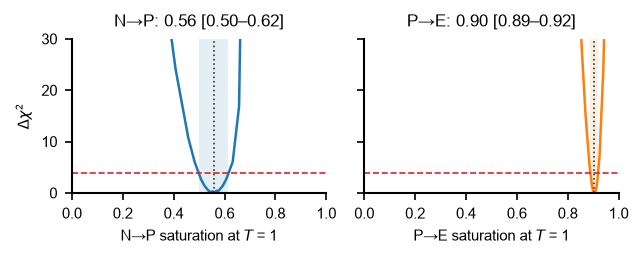

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11 / 2.54, 4.5 / 2.54), sharey=True)
for ax, (w, lab, col, b) in zip(
    axes, [("s_np", "N→P", "#1f77b4", s_np0), ("s_pe", "P→E", "#ff7f0e", s_pe0)]
):
    g = sat[sat.which == w]
    ax.plot(g.achieved, g.dchi2, color=col, lw=1.2)
    ax.axhline(THRESH, color="#d62728", lw=0.8, ls="--")
    ax.axvline(b, color="#333333", lw=0.8, ls=":")
    lo, hi = ci_from_profile(g.achieved, g.dchi2)
    ax.axvspan(lo, hi, color=col, alpha=0.12, lw=0)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 30)
    ax.set_xlabel(f"{lab} saturation at $T$ = 1")
    ax.set_title(f"{lab}: {b:.2f} [{lo:.2f}–{hi:.2f}]", fontsize=8)
axes[0].set_ylabel(r"$\Delta\chi^2$")
fig.tight_layout()
fig.savefig("fig_profile_saturation.pdf")

### Two-dimensional profile in the two Michaelis constants

$K_{m(NP)}$ and $K_{m(PE)}$ are the parameters that set the two saturation levels.
Fixing both on a grid and re-optimising the remaining three parameters gives the
joint confidence region ($\Delta\chi^2\le\chi^2_{0.95,2}=5.99$).

85 s


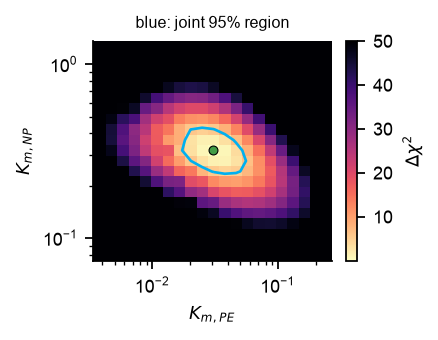

In [9]:
def profile_2d(g_np, g_pe):
    Z = np.full((len(g_np), len(g_pe)), np.nan)
    for i, a in enumerate(g_np):
        x = best.copy()
        for j, b in enumerate(g_pe):
            r = minimize(
                lambda xf: pm.cost(np.r_[xf[0], xf[1], b, xf[2], a], data, **FIT),
                x[[0, 1, 3]],
                method="L-BFGS-B",
                bounds=[pm.BOUNDS[k] for k in (0, 1, 3)],
                options={"maxiter": 2000},
            )
            x = np.r_[r.x[0], r.x[1], b, r.x[2], a]
            Z[i, j] = (pm.cost(x, data, full=True, **FIT)["sse"] - SSE0) / SIG2
    return Z


g_np = np.geomspace(best[4] / 4, best[4] * 4, 21)
g_pe = np.geomspace(best[2] / 8, best[2] * 8, 21)
t0 = time.time()
Z = profile_2d(g_np, g_pe)
print(f"{time.time()-t0:.0f} s")

fig, ax = plt.subplots(figsize=(7 / 2.54, 5.5 / 2.54))
im = ax.pcolormesh(g_pe, g_np, np.clip(Z, 0, 50), cmap="magma_r", shading="nearest")
ax.contour(g_pe, g_np, Z, levels=[5.991], colors="#00b0f0", linewidths=1.2)
ax.plot(best[2], best[4], "o", ms=4, mfc="#419c46", mec="k", mew=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$K_{m,PE}$")
ax.set_ylabel("$K_{m,NP}$")
fig.colorbar(im, ax=ax, label=r"$\Delta\chi^2$")
ax.set_title("blue: joint 95% region", fontsize=7)
fig.tight_layout()
fig.savefig("fig_profile_2d.pdf")

## 3. Bootstrap resampling

Two schemes, because neither alone is fully satisfactory here (the genomic block
has only three points):

* **case resampling**, stratified by dataset — rows are resampled with replacement
  within each imaging and each FRAP dataset; the three TSS ChIP points are held
  fixed (resampling three points with replacement is degenerate);
* **residual resampling** — residuals are resampled with replacement within each
  block and added back to the fitted curve, so *all* blocks including the genomic
  points are perturbed.

In [10]:
def resample(rng, mode, resid):
    b = dict(data)
    if mode == "cases":
        for key, cols in (("E_block", ("T_E", "E", "E_sd")), ("B_block", ("T_B", "B"))):
            idx = np.concatenate(
                [
                    rng.choice(
                        np.where(data[key] == g)[0],
                        (data[key] == g).sum(),
                        replace=True,
                    )
                    for g in np.unique(data[key])
                ]
            )
            for c in cols:
                b[c] = data[c][idx]
            b[key] = data[key][idx]
    else:
        rE, rB, rP = resid
        for r_, key, blk in ((rE, "E", "E_block"), (rB, "B", "B_block")):
            new = np.empty_like(r_)
            for g in np.unique(data[blk]):
                m = data[blk] == g
                new[m] = rng.choice(r_[m], m.sum(), replace=True)
            b[key] = data[key] - r_ + new
        b["P"] = data["P"] - rP + rng.choice(rP, len(rP), replace=True)
    return b


resid = (info0["resid_E"], info0["resid_B"], info0["resid_P"])
t0, rows = time.time(), []
for mode in ("cases", "residual"):
    rng = np.random.default_rng(2024)
    for i in range(300):
        b = resample(rng, mode, resid)
        r = pm.fit(b, n_starts=1, seed=i, x0=best, **FIT)
        s = pm.summarise(r["params"], b, **FIT)
        rows.append({**s, "mode": mode, "rep": i})
boot = pd.DataFrame(rows)
print(f"{time.time()-t0:.0f} s")

cols = [
    "s_np_T1.0",
    "s_pe_T1.0",
    "s_np_T0.7",
    "s_pe_T0.7",
    "T_low",
    "S_T1",
    "Km_np",
    "Km_pe",
    "P0",
]
summary = boot.groupby("mode")[cols].quantile([0.025, 0.5, 0.975]).unstack()
print(summary.round(3).to_string())

786 s
         s_np_T1.0               s_pe_T1.0               s_np_T0.7               s_pe_T0.7                T_low                 S_T1                Km_np                Km_pe                   P0              
             0.025  0.500  0.975     0.025  0.500  0.975     0.025  0.500  0.975     0.025  0.500  0.975  0.025  0.500  0.975  0.025  0.500  0.975  0.025  0.500  0.975  0.025  0.500  0.975  0.025  0.500  0.975
mode                                                                                                                                                                                                             
cases         0.54  0.558  0.568     0.887  0.903  0.917     0.388  0.403  0.413     0.841  0.861  0.879  0.665  0.688  0.709  0.079  0.091  0.104  0.301  0.318  0.342  0.025  0.031  0.041  0.270  0.294  0.330
residual      0.45  0.610  0.829     0.745  0.885  0.929     0.310  0.451  0.701     0.702  0.843  0.890  0.667  0.694  0.725  0.078  0.094  0.115  0.087 

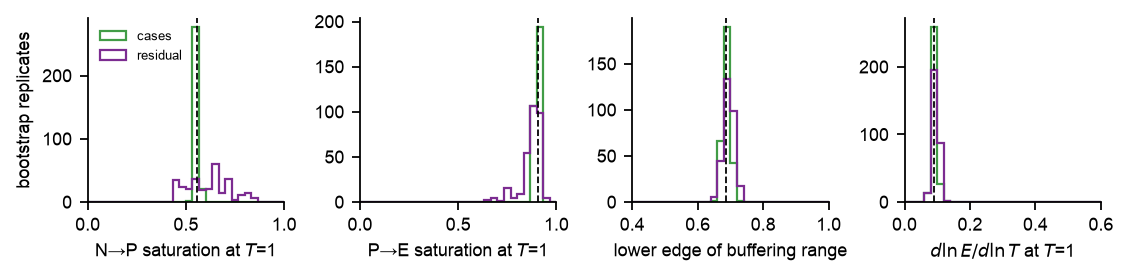

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18 / 2.54, 4.5 / 2.54))
panels = [
    ("s_np_T1.0", "N→P saturation at $T$=1", (0, 1)),
    ("s_pe_T1.0", "P→E saturation at $T$=1", (0, 1)),
    ("T_low", "lower edge of buffering range", (0.4, 1.0)),
    ("S_T1", r"$d\ln E/d\ln T$ at $T$=1", (0, 0.6)),
]
for ax, (c, lab, xl) in zip(axes, panels):
    for mode, col in (("cases", "#419c46"), ("residual", "#7c2c91")):
        v = boot.loc[boot["mode"] == mode, c].dropna()
        ax.hist(v, bins=30, range=xl, histtype="step", color=col, lw=1, label=mode)
    ax.axvline(pm.summarise(best, data, **FIT)[c], color="k", lw=0.8, ls="--")
    ax.set_xlabel(lab)
    ax.set_xlim(*xl)
axes[0].set_ylabel("bootstrap replicates")
axes[0].legend(frameon=False, fontsize=6)
fig.tight_layout()
fig.savefig("fig_bootstrap.pdf")

## 4. Summary table for the response letter

In [12]:
out = []
for c, lab in [
    ("s_np_T1.0", "N→P saturation at T=1"),
    ("s_pe_T1.0", "P→E saturation at T=1"),
    ("s_np_T0.7", "N→P saturation at T=0.7"),
    ("s_pe_T0.7", "P→E saturation at T=0.7"),
    ("T_low", "lower edge of buffering range"),
    ("S_T1", "dlnE/dlnT at T=1"),
    ("Km_np", "Km,NP"),
    ("Km_pe", "Km,PE"),
    ("P0", "P at T=1"),
]:
    r = dict(quantity=lab, best_fit=pm.summarise(best, data, **FIT)[c])
    for mode in ("cases", "residual"):
        v = boot.loc[boot["mode"] == mode, c].dropna()
        r[f"boot_{mode}_2.5%"], r[f"boot_{mode}_97.5%"] = np.percentile(v, [2.5, 97.5])
    out.append(r)
summary_table = pd.DataFrame(out)
for w, c in (("s_np", "N→P saturation at T=1"), ("s_pe", "P→E saturation at T=1")):
    g = sat[sat.which == w]
    lo, hi = ci_from_profile(g.achieved, g.dchi2)
    summary_table.loc[summary_table.quantity == c, "profile_2.5%"] = lo
    summary_table.loc[summary_table.quantity == c, "profile_97.5%"] = hi
summary_table.to_csv("table_identifiability.csv", index=False)
print(summary_table.round(3).to_string(index=False))

                     quantity  best_fit  boot_cases_2.5%  boot_cases_97.5%  boot_residual_2.5%  boot_residual_97.5%  profile_2.5%  profile_97.5%
        N→P saturation at T=1     0.557            0.540             0.568               0.450                0.829         0.499          0.616
        P→E saturation at T=1     0.905            0.887             0.917               0.745                0.929         0.889          0.919
      N→P saturation at T=0.7     0.402            0.388             0.413               0.310                0.701           NaN            NaN
      P→E saturation at T=0.7     0.863            0.841             0.879               0.702                0.890           NaN            NaN
lower edge of buffering range     0.685            0.665             0.709               0.667                0.725           NaN            NaN
             dlnE/dlnT at T=1     0.089            0.079             0.104               0.078                0.115           NaN 